# Project 06 -- Anthony Micco

**TA Help:** None

**Collaboration:** None

**Internet Resources:** None

**ChatGPT, Gemini, Claude, etc:** None

**Link to AI Chat History**: None

**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools.

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

## Question 1

In [32]:
# importing required libraries
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy import signal
from numpy.fft import rfft, rfftfreq

In [33]:
data_path = "/anvil/projects/tdm/data/ravdess"

# Emotion mapping - from the RAVDESS dataset
emotion_mapping = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

In [34]:
#function used to load in audio samples
def load_audio_sample(data_path, emotion_code):
    """Load a sample audio file for a given emotion"""
    for root, dirs, files in os.walk(data_path):
        for filename in files:
            if filename.endswith('.wav'):
                parts = filename.split('-')
                if parts[2] == emotion_code:
                    file_path = os.path.join(root, filename)
                    y, sr = librosa.load(file_path, sr=None)
                    return y, sr, filename
    return None, None, None

In [35]:
#loading in the data
emotions_to_analyze = ['03', '04', '05', '01']  # happy, sad, angry, neutral
audio_samples = {}

for emotion_code in emotions_to_analyze:
    y, sr, filename = load_audio_sample(data_path, emotion_code)
    if y is not None:
        emotion_name = emotion_mapping[emotion_code]
        audio_samples[emotion_name] = {'signal': y, 'sample_rate': sr, 'filename': filename}
        print(f"Loaded {emotion_name}: {filename}")
        print(f"  Duration: {len(y)/sr:.2f} seconds")
        print(f"  Number of samples: {len(y)}")
        print(f"  Sample rate: {sr} Hz\n")

Loaded happy: 03-01-03-02-02-01-03.wav
  Duration: 4.14 seconds
  Number of samples: 198598
  Sample rate: 48000 Hz

Loaded sad: 03-01-04-01-01-01-03.wav
  Duration: 3.60 seconds
  Number of samples: 172973
  Sample rate: 48000 Hz

Loaded angry: 03-01-05-02-02-01-03.wav
  Duration: 4.24 seconds
  Number of samples: 203403
  Sample rate: 48000 Hz

Loaded neutral: 03-01-01-01-02-01-03.wav
  Duration: 3.50 seconds
  Number of samples: 168168
  Sample rate: 48000 Hz



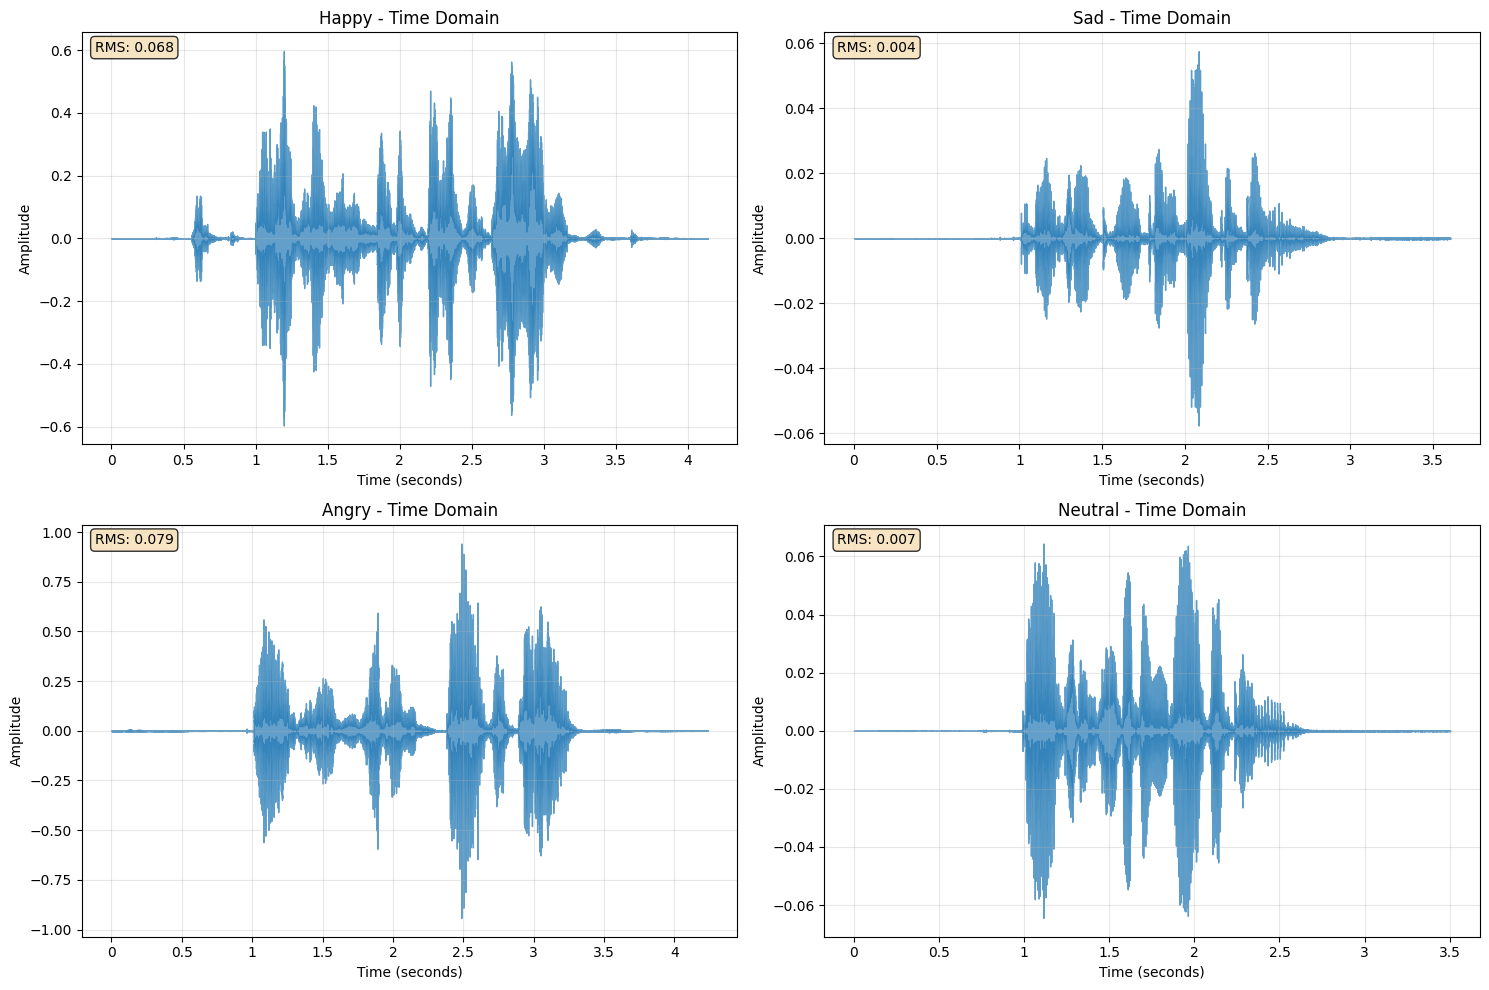

In [36]:
#plotting the signals of the dataset
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, (emotion, data) in enumerate(audio_samples.items()):
    y = data['signal']
    sr = data['sample_rate']

    librosa.display.waveshow(y, sr=sr, ax=axes[i], alpha=0.7)
    axes[i].set_title(f'{emotion.capitalize()} - Time Domain')
    axes[i].set_xlabel('Time (seconds)')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)

    # Adding some statistics to each graph
    rms = np.sqrt(np.mean(y**2))
    axes[i].text(0.02, 0.98, f'RMS: {rms:.3f}', transform=axes[i].transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

1.3) One of the patterns I notice in the waveforms is that the Happy Time Domain is the only time domain to have any significant sound recorded before 1 second. The rest of the emotion time domains all begin producing significant sound around the 1 second mark. Additionally, each time domain tends to stop recording any sound around the 3-3.5 second mark of the the graph. The emotions that appear the most similar are the Happy and Neutral emotions and the Angry and Sad emotions. I believe this is because Angry and Sad are both associated with negative emotions and tend to involve more somber, softer music, while happy and neutral are more positive so they involve louder, more upbeat music. 

## Question 2

In [37]:
#converting time domain values to frequency-domain representation
fft_vals = rfft(y)

In [38]:
#calculating magnitude and frequency from fft_vals
magnitude = np.abs(fft_vals)       # amplitude of each frequency bin
frequency = rfftfreq(len(y), 1/sr)  # corresponding frequencies (Hz)

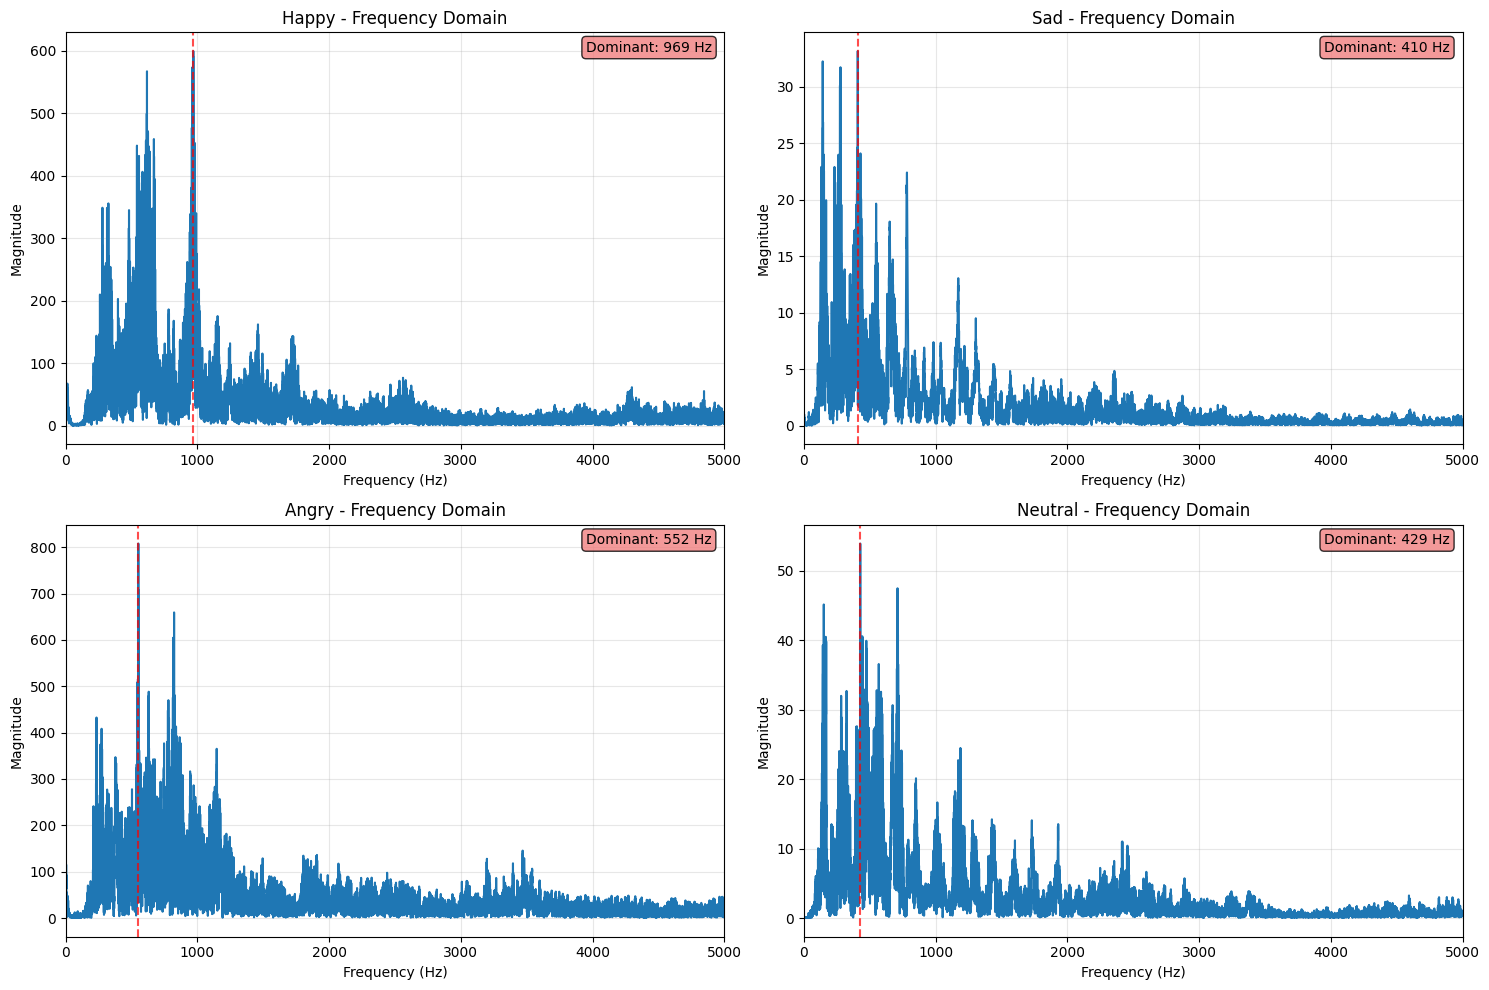

In [39]:
#graphing the different emotions in the frequency domain
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, (emotion, data) in enumerate(audio_samples.items()):
    y = data['signal']
    sr = data['sample_rate']

    # -- Compute FFT -- #
    #converting time domain values to frequency-domain representation
    fft_vals = rfft(y)

    #calculating magnitude and frequency
    magnitude = np.abs(fft_vals)
    frequency = rfftfreq(len(y), 1/sr)
    # -- ----------- -- #

    # Plot emotion in the frequency domain - frequency vs magnitude
    axes[i].plot(frequency, magnitude)
    axes[i].set_title(f'{emotion.capitalize()} - Frequency Domain')
    axes[i].set_xlabel('Frequency (Hz)')
    axes[i].set_ylabel('Magnitude')
    axes[i].set_xlim(0, 5000)  # Limit scope to typical speech frequencies
    axes[i].grid(True, alpha=0.3)

    # Find dominant frequency & plot it - the frequency with the highest magnitude
    dominant_freq_idx = np.argmax(magnitude)
    dominant_freq = frequency[dominant_freq_idx]
    axes[i].axvline(dominant_freq, color='red', linestyle='--', alpha=0.7)
    axes[i].text(0.79, 0.98, f'Dominant: {dominant_freq:.0f} Hz',
                transform=axes[i].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

plt.tight_layout()
plt.show()

2.2) The dominant frequency of Happy was much higher than the other three emotions as Happy's dominant frequency was 969 hz, while the next closest was Angry's dominant frequency of 552 hz. All the graphs have a right skewed frequency distribution as there tend to be a higher number of frequencies in the 0-2000 hz range in each emotion than any other range. Despite their similarities, the magnitude of these frequencies differs between emotions. The Happy and Angry emotions have magnitudes that scale between 600 and 800 respectively, while the Sad and Neutral emotions have magnitudes that only scale between 30 and 50. In addition to similar magnitude scales, these pairs of emotions have similar frequency distributions. The reasoning behind these relationships could be that Happy and Angry are more expressive and passionate emotions, so they have a greater number of these frequencies present in their audios as compared to the more somber Neutral and Sad emotions. 

## Question 3

In [40]:
#filtering out the "Happy" data and creating window and hop size parameters
happy_data = audio_samples['happy']

window_size = 1024
hop_size = 512

y = happy_data['signal']
sr = happy_data['sample_rate']

In [41]:
#retrieving basic summary information
windows = []
window_times = []

# Creates the windows - length window_size, each iteration moves up by hop_size
for start in range(0, len(y) - window_size, hop_size):
    window = y[start:start + window_size]
    windows.append(window)
    window_times.append(start / sr) # will get the time in seconds

# Some basic summary information
print(f"Signal length: {len(y)} samples ({len(y)/sr:.2f} seconds)")
print(f"Window size: {window_size} samples ({window_size/sr:.3f} seconds)")
print(f"Hop size: {hop_size} samples ({hop_size/sr:.3f} seconds)")
print(f"Number of windows: {len(windows)}")
print(f"Window overlap: {((window_size - hop_size) / window_size) * 100:.1f}%")

Signal length: 198598 samples (4.14 seconds)
Window size: 1024 samples (0.021 seconds)
Hop size: 512 samples (0.011 seconds)
Number of windows: 386
Window overlap: 50.0%


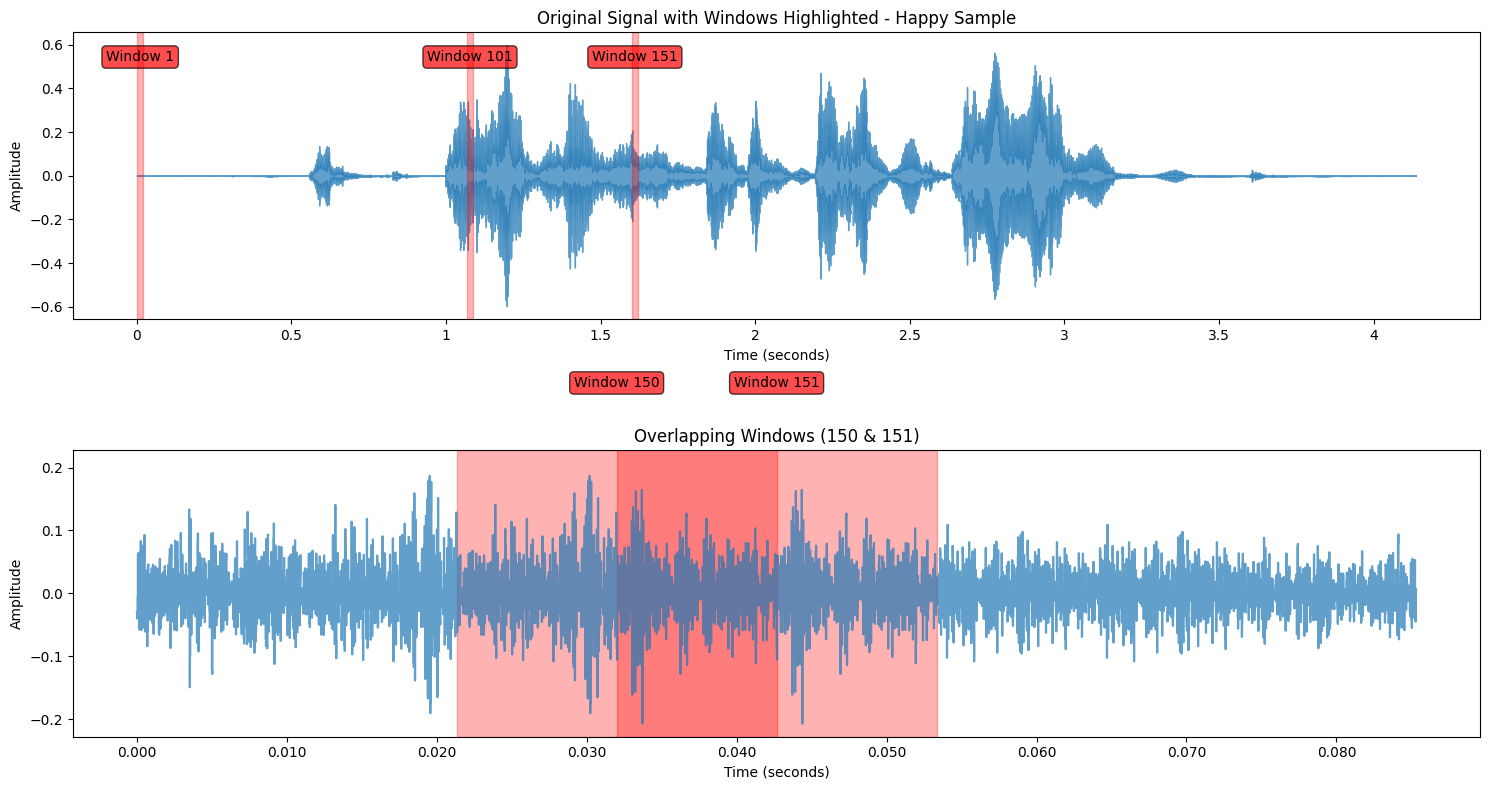

In [42]:
#plotting the windows
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))

# Original time signal
librosa.display.waveshow(y, sr=sr, ax=ax1, alpha=0.7)
ax1.set_title('Original Signal with Windows Highlighted - Happy Sample')
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Amplitude')

# Highlight a few windows
for i in [0, 100, 150]:  # Show windows 1, 51, and 101
    window_start = i * hop_size / sr
    window_end = window_start + window_size / sr
    ax1.axvspan(window_start, window_end, alpha=0.3, color='red')
    ax1.text(window_start + (window_end - window_start)/2,
             ax1.get_ylim()[1]*0.8, f'Window {i+1}', ha='center',
             bbox=dict(boxstyle='round', facecolor='red', alpha=0.7))

# Show the overlap between windows
librosa.display.waveshow(np.concatenate(windows[148:152]), sr=sr, ax=ax2, alpha=0.7)
ax2.set_title('Overlapping Windows (150 & 151)')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Amplitude')

for i in [2, 3]:  # Highlight windows 150 and 151
    window_start = i * hop_size / sr
    window_end = window_start + window_size / sr
    ax2.axvspan(window_start, window_end, alpha=0.3, color='red')
    ax2.text(window_start + (window_end - window_start)/2,
             ax1.get_ylim()[1]*0.5, f'Window {i+148}', ha='center',
             bbox=dict(boxstyle='round', facecolor='red', alpha=0.7))

plt.tight_layout()
plt.show()

In [43]:
#applying the Hann window
segment = windows[149]

hann_window = segment * np.hanning(len(segment)) # Apply the hann window to the segment

# FFT for both original and windowed segments
fft_original = np.abs(rfft(segment)) # gets magnitude of them
fft_hann = np.abs(rfft(hann_window))

frequency = rfftfreq(len(segment), 1/sr)

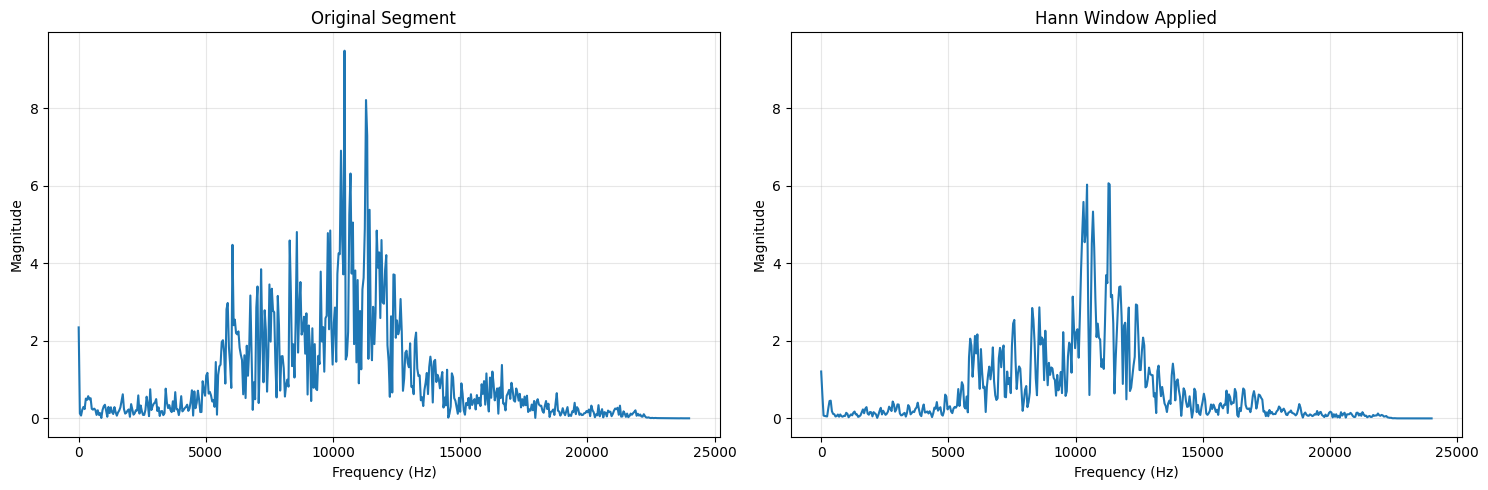

In [44]:
#comparing plot of original segment to hann window segment
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(frequency, fft_original)
ax1.set_title('Original Segment')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Magnitude')
ax1.grid(True, alpha=0.3)

ax2.plot(frequency, fft_hann)
ax2.set_title('Hann Window Applied')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude')
ax2.set_ylim(ax1.get_ylim())  # Match scales for fair comparison
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

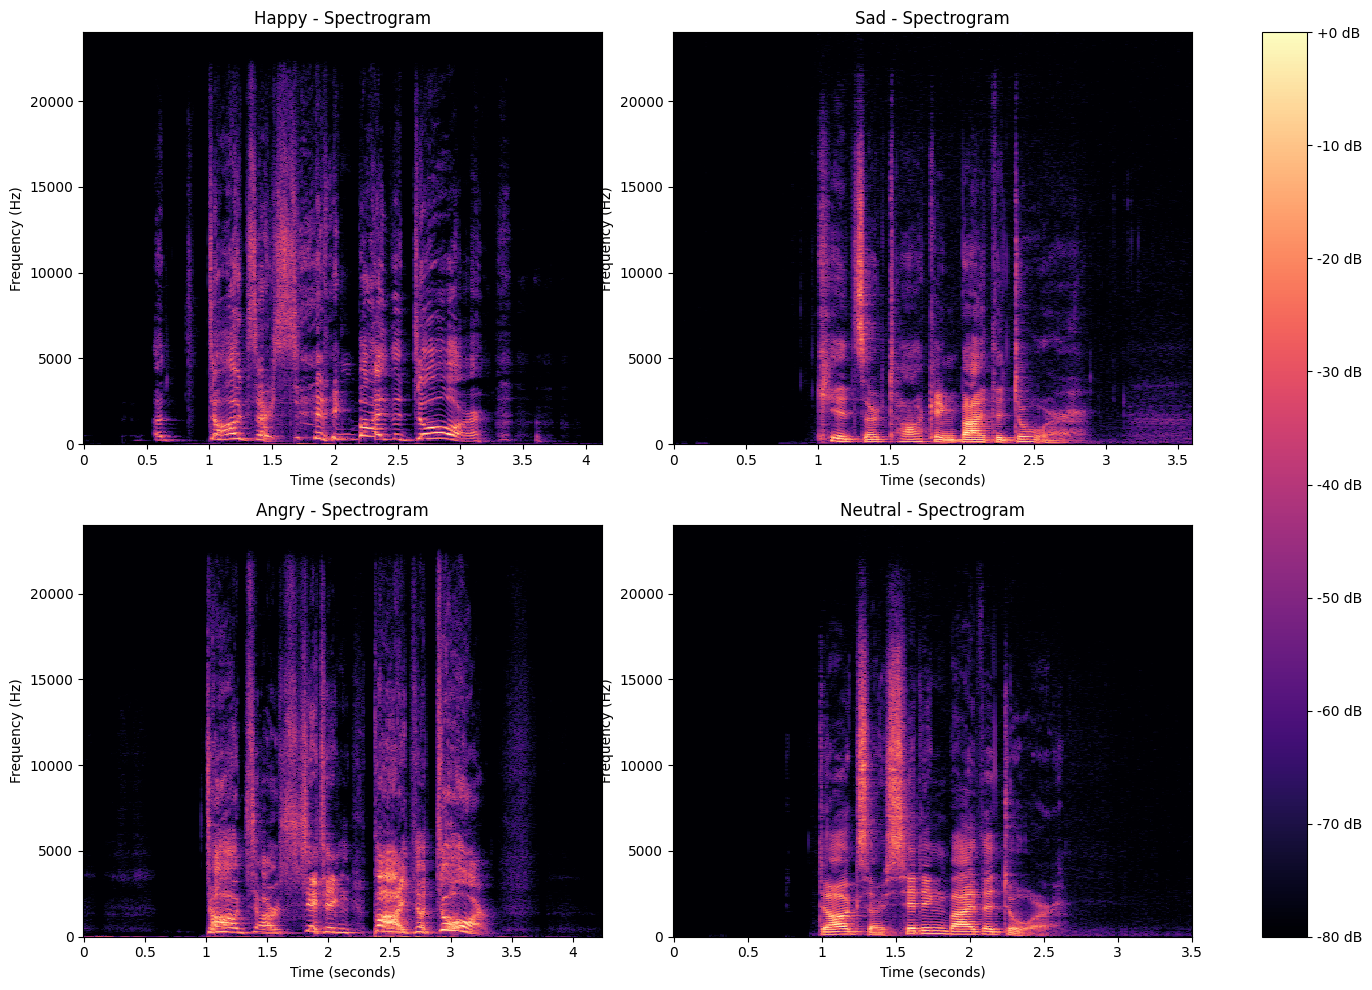

In [45]:
#creating spectrogram of the windows
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, (emotion, data) in enumerate(audio_samples.items()):
    y = data['signal']
    sr = data['sample_rate']

    # Create spectrogram using librosa's stft function
    fft_vals = np.abs(librosa.stft(y))
    D = librosa.amplitude_to_db(fft_vals, ref=np.max)
    img = librosa.display.specshow(D, y_axis='linear', x_axis='time',
                                 sr=sr, ax=axes[i])
    axes[i].set_title(f'{emotion.title()} - Spectrogram')
    axes[i].set_xlabel('Time (seconds)')
    axes[i].set_ylabel('Frequency (Hz)')

plt.tight_layout()
plt.colorbar(img, ax=axes, format='%+2.0f dB')
plt.show()

3.4) Tha Hann Window improves the frequency analysis compared to no window by reducing excess noise at the edges of each segment in the frequency analysis. It essentially uses weights at the ends of each frequency segment to ensure there is a smooth transition from one frequency segment to the next.  \
3.5) One pattern I notice is that in each emotion, the decibel level of each emotion is mostly concentrated within the -30 dB to -80 dB range, and the higher decibel levels occur mostly below 5000 hz. The emotions with the most dynamic frequency changes are the Angry and Sad emotions as there are multiple times where the frequency is around 20000 hz and then immediately drops to below 5000 hz and then shoots back up to 20000 hz.  

## Question 4

In [46]:
#loading in the Happy sample
happy_data = audio_samples['happy']

y = happy_data['signal']
sr = happy_data['sample_rate']

In [47]:
#generating a lowpass filter
lowpass_cutoff = 3000
lowpass_b, lowpass_a = signal.butter(4, lowpass_cutoff / (sr / 2), btype='low')

In [48]:
#generating a highpass filter
highpass_cutoff = 300
highpass_b, highpass_a = signal.butter(4, highpass_cutoff / (sr / 2), btype='high')

In [49]:
#generating a bandpass filter
bandpass_low = 300
bandpass_high = 5000
bandpass_b, bandpass_a = signal.butter(4, [bandpass_low / (sr / 2), bandpass_high / (sr / 2)], btype='band')

In [50]:
#applying the filters using signal.filtfilt()
y_lowpass = signal.filtfilt(lowpass_b, lowpass_a, y)
y_highpass = signal.filtfilt(highpass_b, highpass_a, y)
y_bandpass = signal.filtfilt(bandpass_b, bandpass_a, y)

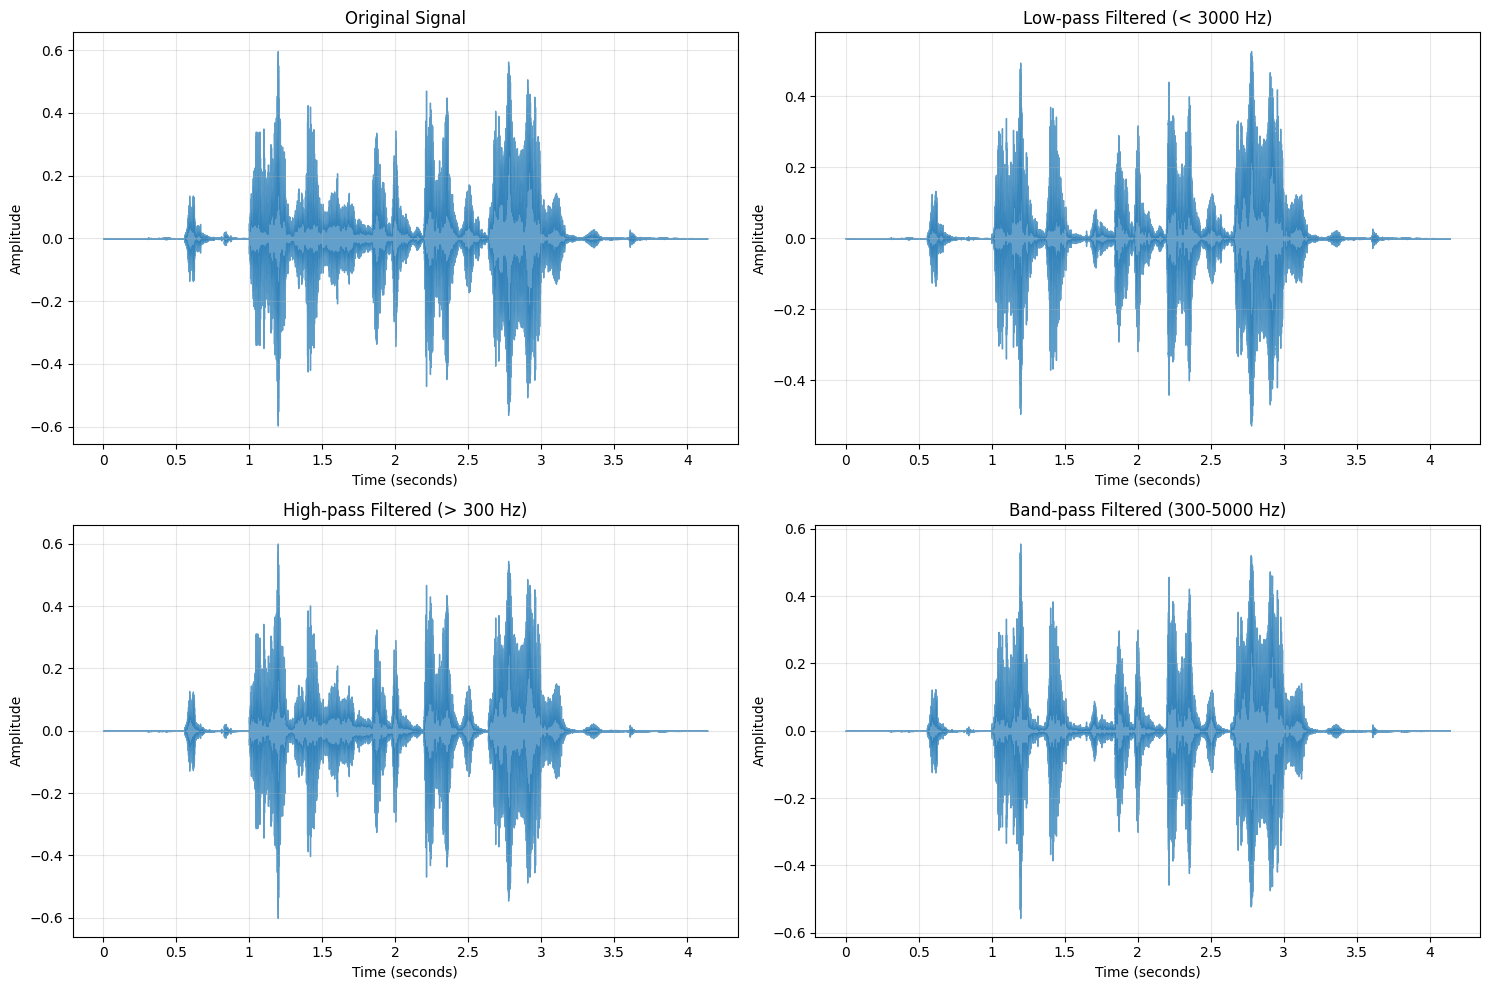

In [51]:
#graphing the filtered signals and the original signal
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

filters = [
    (y, 'Original Signal'),
    (y_lowpass, f'Low-pass Filtered (< {lowpass_cutoff} Hz)'),
    (y_highpass, f'High-pass Filtered (> {highpass_cutoff} Hz)'),
    (y_bandpass, f'Band-pass Filtered ({bandpass_low}-{bandpass_high} Hz)')
]

for i, (y_filtered, title) in enumerate(filters):
    librosa.display.waveshow(y_filtered, sr=sr, ax=axes[i], alpha=0.7)
    axes[i].set_title(title)
    axes[i].set_xlabel('Time (seconds)')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [52]:
#performing fft on the filtered signals
fft_original = np.abs(librosa.stft(y))
fft_lowpass = np.abs(librosa.stft(y_lowpass))
fft_highpass = np.abs(librosa.stft(y_highpass))
fft_bandpass = np.abs(librosa.stft(y_bandpass))

frequency = librosa.fft_frequencies(sr=sr)

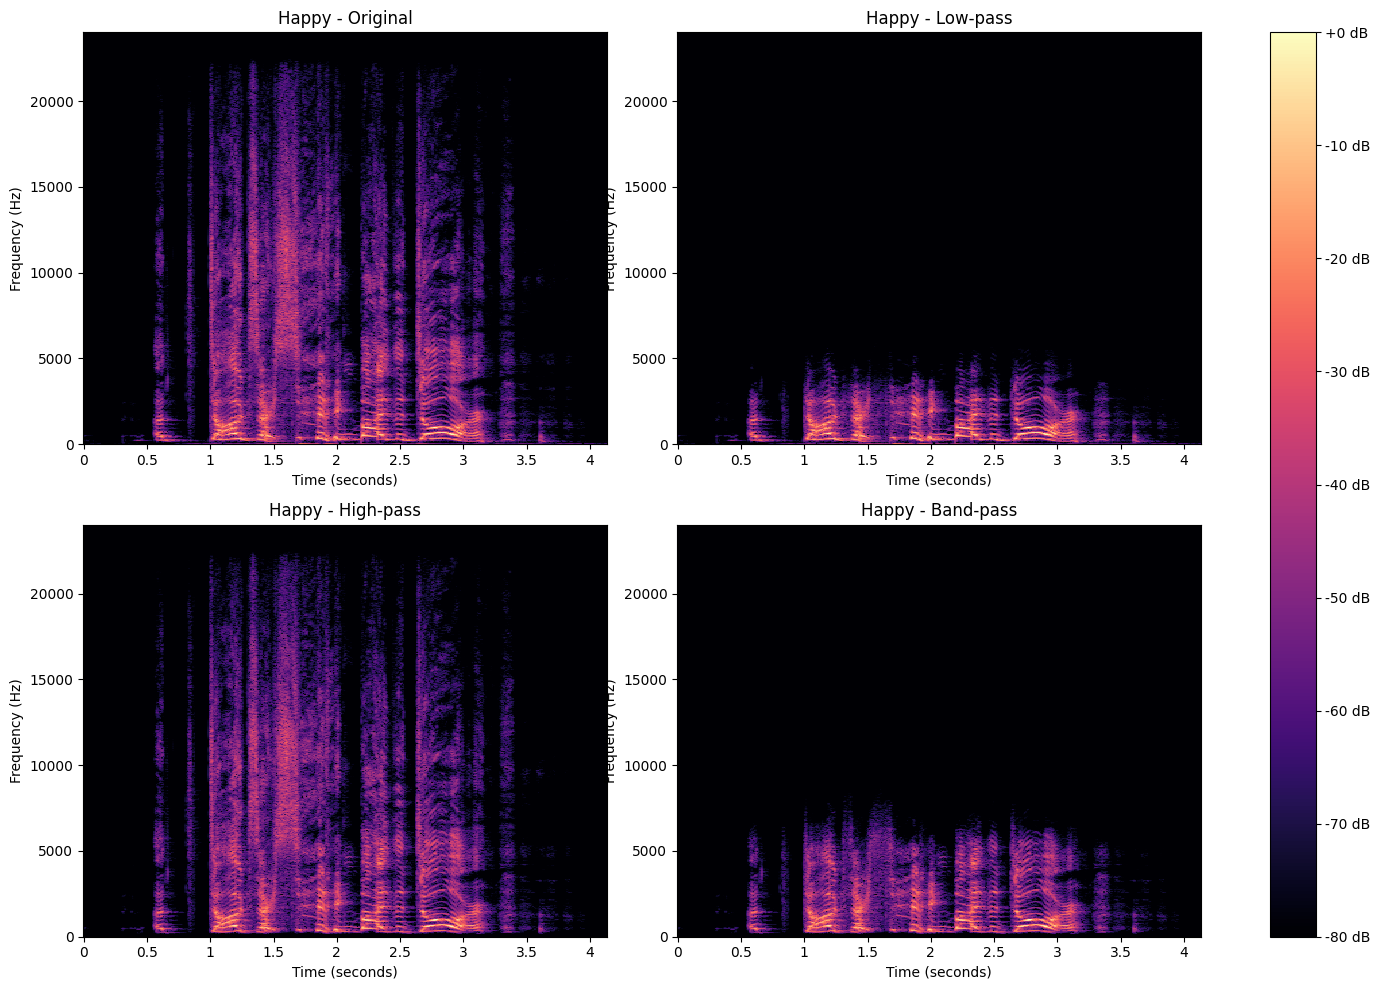

In [53]:
#plotting the spectrograms
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

signals = [
    ('Original', fft_original),
    ('Low-pass', fft_lowpass),
    ('High-pass', fft_highpass),
    ('Band-pass', fft_bandpass)
]

for i, (name, fft_vals) in enumerate(signals):
    D = librosa.amplitude_to_db(fft_vals, ref=np.max)
    img = librosa.display.specshow(D, y_axis='linear', x_axis='time',
                                 sr=sr, ax=axes[i])
    axes[i].set_title(f'Happy - {name}')
    axes[i].set_xlabel('Time (seconds)')
    axes[i].set_ylabel('Frequency (Hz)')

plt.tight_layout()
plt.colorbar(img, ax=axes, format='%+2.0f dB')
plt.show()

4.3) Low-pass filters out all frequencies greater than 3000 hz, while high-pass filters out all frequencies less than 300 hz and band-pass filters out frequencies less than 300 hz and greater than 5000 hz. Based on the spectrogram, higher frequencies are most impacted by the low-pass and band-pass filters, while lower frequencies are most impacted by the high-pass filter. \
4.4) The high-pass filter would be most effective at removing background noise because it only allows higher frequencies to pass and generally background noise is a lower frequency so the high-pass filter would be effective in removing the background noise.\
4.5) The band-pass filter preserves the most speech intelligibility because it filters based on a range provided by us, so if we give it a range most often associated with speech (300-5000 hz), then it will better capture speech intelligibility better the other two which filter out frequencies higher or lower than the threshold we provide. 

## Question 5

In [54]:
# calculating statistical features from the data
happy_data = audio_samples['happy']

y = happy_data['signal']
sr = happy_data['sample_rate']

features = {}

features['mean'] = np.mean(y)
features['std'] = np.std(y)
features['rms'] = np.sqrt(np.mean(y**2))
features['zero_crossing_rate'] = np.median(librosa.feature.zero_crossing_rate(y))

In [55]:
# extracting spectral features 
# Spectral centroid - indicates the "center of mass" of the spectrum
centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
features['spectral_centroid'] = np.mean(centroid)

# Spectral rolloff - frequency below which 85% of energy is contained
rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
features['spectral_rolloff'] = np.mean(rolloff)

In [56]:
#extracting MFCCs 
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13) # n_mfcc=13 is the standard
features['mfcc_1'] = np.mean(mfccs[0])
features['mfcc_2'] = np.mean(mfccs[1])
features['mfcc_3'] = np.mean(mfccs[2])
features['mfcc_4'] = np.mean(mfccs[3])

In [57]:
#extracting these features for each emotion
all_features = {}
for emotion, data in audio_samples.items():
    y = data['signal']
    sr = data['sample_rate']

    features = {}

    #extracting statistical features
    features['mean'] = np.mean(y)
    features['std'] = np.std(y)
    features['rms'] = np.sqrt(np.mean(y**2))
    features['zero_crossing_rate'] = np.median(librosa.feature.zero_crossing_rate(y))

    #extracting spectral features
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features['spectral_centroid'] = np.mean(centroid)

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
    features['spectral_rolloff'] = np.mean(rolloff)

    #extracting MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    index = 1
    for x in range(0,len(mfccs)):
        features[f'mfcc_{index}'] = np.mean(mfccs[x])
        index += 1

    all_features[emotion] = features

In [58]:
#creating a table of all the values
# Dynamically grab the features - happy is arbitrarily picked
feature_names = list(all_features['happy'].keys())

print("Feature Comparison Across Emotions:")
print("=" * 80)
print(f"{'Feature':<20} {'Happy':<12} {'Sad':<12} {'Angry':<12} {'Neutral':<12}")
print("-" * 80)

for feature in feature_names:
    values = [all_features[emotion][feature] for emotion in ['happy', 'sad', 'angry', 'neutral']]
    print(f"{feature:<20} {values[0]:<12.4f} {values[1]:<12.4f} {values[2]:<12.4f} {values[3]:<12.4f}")

print("-" * 80)

Feature Comparison Across Emotions:
Feature              Happy        Sad          Angry        Neutral     
--------------------------------------------------------------------------------
mean                 0.0000       -0.0000      -0.0000      -0.0000     
std                  0.0680       0.0040       0.0793       0.0071      
rms                  0.0680       0.0040       0.0793       0.0071      
zero_crossing_rate   0.0527       0.0386       0.0610       0.0435      
spectral_centroid    4579.8847    5154.8361    4526.9290    5650.3365   
spectral_rolloff     9384.9066    9764.9778    8977.1514    10482.1191  
mfcc_1               -382.6595    -691.9238    -385.5774    -662.1957   
mfcc_2               63.6372      94.6712      71.5252      81.6330     
mfcc_3               -11.7864     0.4767       -18.2755     -3.5777     
mfcc_4               12.9491      12.3436      11.2321      16.8320     
mfcc_5               -14.5424     0.8991       -5.0841      1.7413      
mfcc_6 

5.2) Angry has the highest RMS which tells us that this emotional expression is the loudest and has the highest energy of any of the emotions. \
5.3) Neutral has the highest spectral centroid which indicates to us that Neutral's speech characteristics are "brighter" and have a higher frequency energy, so they are more upbeat than the other emotions. \
5.4) The Angry and Happy emotions both have zero crossing rates greater than 0.05 with rates of 0.0610 and 0.0527 respectively, while Sad and Neutral both have zero crossing rates less than 0.05 with respective rates of 0.0386 and 0.0435. This statistic measures how many times a signal changes sign per frame which results in varying values because a higher ZCR means a higher frequency/louder signal, while a lower ZCR means a lower frequency/quieter signal. With emotional expressions such as the ones we work with, there can be varying ZCR values because the signal may fade or stay consistent depending on the emotion. 

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
